In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
from PIL import Image

image_folder_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/input/Flipkart/Images'
output_folder_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/Flipkart/Images_resized_vgg16'

# Create the output directory if it doesn't exist
os.makedirs(output_folder_path, exist_ok=True)

# Define the target size for VGG16
target_size = (224, 224)

# List all files in the directory
image_files = [f for f in os.listdir(image_folder_path) if os.path.isfile(os.path.join(image_folder_path, f))]

print(f"Found {len(image_files)} files in the input directory.")

if not image_files:
    print("No image files found in the input directory.")
else:
    print(f"Resizing and saving images to {output_folder_path}...")
    for i, image_file in enumerate(image_files):
        try:
            img_path = os.path.join(image_folder_path, image_file)
            img = Image.open(img_path)

            # Resize the image
            img_resized = img.resize(target_size)

            # Save the resized image
            output_path = os.path.join(output_folder_path, image_file)
            img_resized.save(output_path)

            if (i + 1) % 100 == 0:
                print(f"Processed {i + 1}/{len(image_files)} images.")

        except Exception as e:
            print(f"  - Could not process {image_file}: {e}")

    print("Image resizing and saving complete.")

Found 1050 files in the directory.
Analyzing image properties (sampling the first 10 images if there are many):
  - 06fdaa2b03d70da4358311d260456729.jpg: 1100x728, Format: JPEG
  - 0d02f4703fde00645704e15bba23e77d.jpg: 481x471, Format: JPEG
  - 109e235d4838002246599f987d935c21.jpg: 1370x1152, Format: JPEG
  - 08e8af585235d7403ca2b7b56a51a6d4.jpg: 1000x667, Format: JPEG
  - 09f9f9b420edea2f39c0dc3c24d5be07.jpg: 3557x3432, Format: JPEG
  - 0ca8e323551dd7107ef57ef7c3e77aee.jpg: 1400x1440, Format: JPEG
  - 079d049de21fb2426b516a8d2f9a8bdb.jpg: 3677x3000, Format: JPEG
  - 0c4718ae90f2889b7021a99ee1cc106c.jpg: 2800x1488, Format: JPEG
  - 0906fd9cc604fbba05a502e01d763cd9.jpg: 1245x1100, Format: JPEG
  - 136f213080426c35520f1b1540c4a390.jpg: 1100x543, Format: JPEG
  - 093bcad64d11c0aed903a8dd787ef069.jpg: 1011x1100, Format: JPEG
  - 0ae859a69c7608d8197c3ba8c37bc6ec.jpg: 1000x1100, Format: JPEG
  - 0e1e3861d54a8a17b7b91f04071a4ca3.jpg: 954x516, Format: JPEG
  - 08452abdadb3db1e686b94a9c52fc7b6.

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


  - 59af3731b809a25f2bf99e99f645d8dd.jpg: 1100x993, Format: JPEG
  - 621a88993a7033df3440ec816c2e386f.jpg: 1100x948, Format: JPEG
  - 53f4bc7d7321f5c41de6b86e41f13e80.jpg: 2000x1900, Format: JPEG
  - 59247d4024d85bfaf9e48368cba6d870.jpg: 5280x2472, Format: JPEG
  - 5cd3d274d71e1e0d6bf075421461b2d5.jpg: 1400x1000, Format: JPEG
  - 526cb1e7675adb39a1ea68f1f2a3fd59.jpg: 648x1100, Format: JPEG
  - 597a9549a3e397d52dca62ee47b1f60a.jpg: 1100x839, Format: JPEG
  - 5912e037d12774bb73a2048f35a00009.jpg: 1100x1011, Format: JPEG
  - 59d964c38c787f829c6cfa5629e4df90.jpg: 792x1353, Format: JPEG
  - 52877a6306aef18af67ab54c8233c931.jpg: 1100x795, Format: JPEG
  - 568f331e1039bf2e0635b899c2b3248f.jpg: 1435x1274, Format: JPEG
  - 5db6bd89da44841c1a5b686e67137704.jpg: 232x504, Format: JPEG
  - 51dc964c7a47293ff0ed0c6912813722.jpg: 855x1100, Format: JPEG
  - 5325213d84c80ad310b6e4b37a1ac824.jpg: 607x1057, Format: JPEG
  - 5c0fe2919e49f30aff91d46800cdf149.jpg: 2277x2972, Format: JPEG
  - 539f82930cfad8af

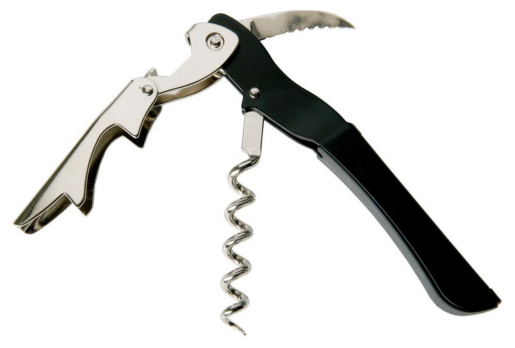

In [ ]:
# analyse exploratoire de données des images présent dans le dossier

import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

image_folder_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/input/Flipkart/Images'

# List all files in the directory
image_files = [f for f in os.listdir(image_folder_path) if os.path.isfile(os.path.join(image_folder_path, f))]

print(f"Found {len(image_files)} files in the directory.")

if not image_files:
    print("No image files found in the directory.")
else:
    # Let's analyze some properties of the images
    image_widths = []
    image_heights = []
    image_formats = []

    print("Analyzing image properties (sampling the first 10 images if there are many):")
    # for i, image_file in enumerate(image_files[:10]): # Analyze the first 10 for efficiency
    for i, image_file in enumerate(image_files): # Analyze the first 10 for efficiency
        try:
            img_path = os.path.join(image_folder_path, image_file)
            with Image.open(img_path) as img:
                image_widths.append(img.width)
                image_heights.append(img.height)
                image_formats.append(img.format)
                print(f"  - {image_file}: {img.width}x{img.height}, Format: {img.format}")
        except Exception as e:
            print(f"  - Could not open or read {image_file}: {e}")

    if image_widths and image_heights:
        avg_width = np.mean(image_widths)
        avg_height = np.mean(image_heights)

        print(f"\nAverage image dimensions (based on sampled images): {avg_width:.2f}x{avg_height:.2f}")

        print("\nMost common image formats (based on sampled images):")
        format_counts = {}
        for fmt in image_formats:
            format_counts[fmt] = format_counts.get(fmt, 0) + 1
        for fmt, count in format_counts.items():
            print(f"  - {fmt}: {count}")

        # Display a sample image
        try:
            sample_image_path = os.path.join(image_folder_path, image_files[0])
            print(f"\nDisplaying a sample image: {image_files[0]}")
            img = Image.open(sample_image_path)
            plt.imshow(img)
            plt.axis('off') # Hide axes
            plt.show()
        except Exception as e:
            print(f"Could not display sample image: {e}")
    else:
        print("\nCould not gather image properties from the sampled files.")




Recherche d'outliers dans les dimensions des images:

Résumé statistique des dimensions des images:

Potential outliers in image width (using IQR):
  Indices: [4, 6, 7, 34, 40, 44, 63, 71, 93, 95, 110, 114, 118, 131, 134, 143, 145, 147, 153, 156, 160, 186, 194, 200, 220, 233, 238, 257, 265, 268, 286, 287, 298, 317, 324, 327, 333, 334, 350, 353, 357, 366, 367, 370, 382, 387, 390, 411, 415, 430, 432, 434, 483, 491, 500, 515, 517, 518, 524, 529, 530, 540, 542, 558, 562, 566, 589, 600, 603, 609, 633, 638, 639, 646, 647, 652, 656, 662, 668, 669, 670, 672, 684, 690, 702, 712, 714, 715, 730, 731, 732, 739, 742, 746, 776, 779, 782, 795, 805, 813, 821, 822, 824, 838, 851, 854, 856, 876, 903, 905, 917, 919, 929, 933, 936, 939, 940, 962, 980, 982, 1010, 1025, 1047, 1049]
  Files: ['09f9f9b420edea2f39c0dc3c24d5be07.jpg', '079d049de21fb2426b516a8d2f9a8bdb.jpg', '0c4718ae90f2889b7021a99ee1cc106c.jpg', '0e73201f6d8807776e1d21c969078289.jpg', '13596c5cc53a74268613e5c0b7d46b60.jpg', '10b6738d7058738a9

,width,height
4,3557,3432
6,3677,3000
7,2800,1488
34,2184,992
40,4952,1136
...,...,...
982,2655,2606
1010,3908,3908
1025,4131,3286
1047,4433,2455



Potential outliers in image height (using IQR):
  Indices: [4, 6, 18, 38, 44, 63, 110, 143, 145, 148, 153, 156, 160, 170, 175, 185, 186, 204, 217, 220, 238, 250, 257, 265, 268, 287, 298, 316, 317, 333, 334, 350, 353, 387, 390, 395, 411, 430, 471, 483, 491, 493, 498, 510, 515, 517, 518, 530, 540, 542, 565, 566, 589, 603, 609, 633, 635, 652, 656, 662, 664, 668, 669, 672, 684, 690, 702, 724, 730, 739, 758, 782, 795, 816, 818, 822, 838, 851, 894, 903, 917, 939, 940, 945, 980, 982, 1002, 1010, 1025, 1047]
  Files: ['09f9f9b420edea2f39c0dc3c24d5be07.jpg', '079d049de21fb2426b516a8d2f9a8bdb.jpg', '0bb0f7b7a3075f4b9459121abe2185fa.jpg', '0bff0eda7a6677dc1acb0477a1f7a121.jpg', '10b6738d7058738a9a7d107bbb2833f4.jpg', '216c6c3527984be3d7ad9023d5cd9bd1.jpg', '22ac36ba254a68d7dd6173f099771147.jpg', '387ecd9ec173d61b6dc5ceddc079b150.jpg', '3bc98543c7dd0d8fce5b8185b4a58c43.jpg', '2e474c49a7dfe704c35cf3990740daa3.jpg', '2e8df36b35d22cf219cf8bae6c2af752.jpg', '36b965559aa2b97cb961a603f18a9183.jpg', '36

,width,height
4,3557,3432
6,3677,3000
18,1529,2839
38,1588,2504
44,2791,2875
...,...,...
982,2655,2606
1002,788,2430
1010,3908,3908
1025,4131,3286



Visualisation des distributions des dimensions des images pour repérer les outliers:


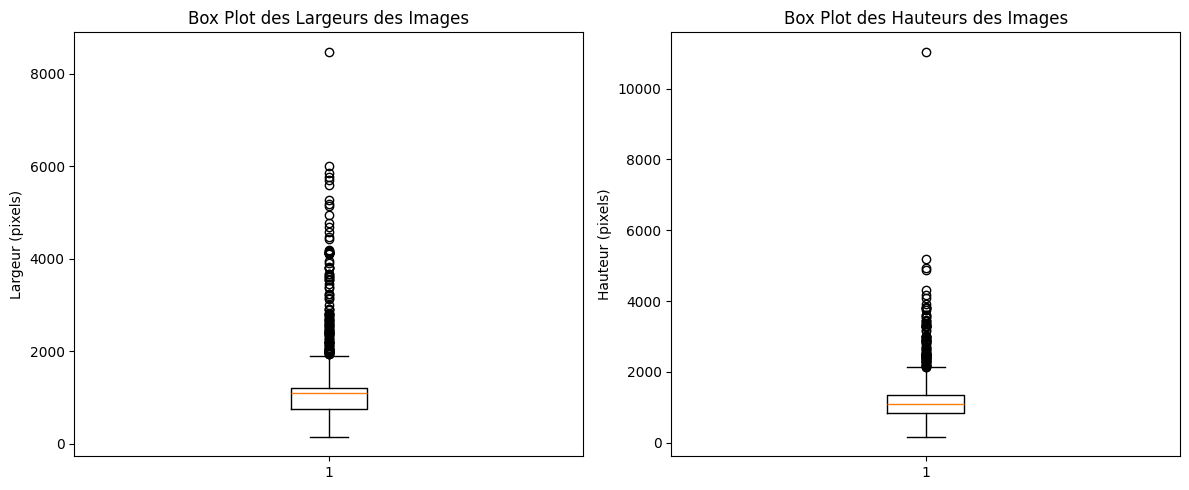

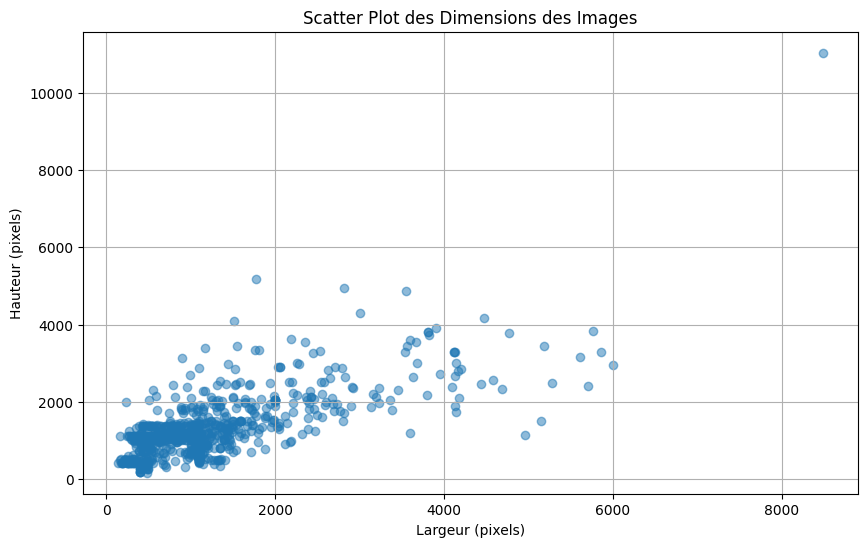

In [ ]:
import pandas as pd # Import pandas

print("\nRecherche d'outliers dans les dimensions des images:")

if image_widths and image_heights:
    # Create a DataFrame for image dimensions to easily use describe() and other methods
    image_df = pd.DataFrame({
        'width': image_widths,
        'height': image_heights
    })

    print("\nRésumé statistique des dimensions des images:")
    image_df.describe()

    # Identify potential outliers using the IQR method for image dimensions
    Q1_width = image_df['width'].quantile(0.25)
    Q3_width = image_df['width'].quantile(0.75)
    IQR_width = Q3_width - Q1_width
    lower_bound_width = Q1_width - 1.5 * IQR_width
    upper_bound_width = Q3_width + 1.5 * IQR_width

    Q1_height = image_df['height'].quantile(0.25)
    Q3_height = image_df['height'].quantile(0.75)
    IQR_height = Q3_height - Q1_height
    lower_bound_height = Q1_height - 1.5 * IQR_height
    upper_bound_height = Q3_height + 1.5 * IQR_height

    outliers_width = image_df[(image_df['width'] < lower_bound_width) | (image_df['width'] > upper_bound_width)]
    outliers_height = image_df[(image_df['height'] < lower_bound_height) | (image_df['height'] > upper_bound_height)]

    print(f"\nPotential outliers in image width (using IQR):")
    if not outliers_width.empty:
        # Find the original image files corresponding to these outliers
        outlier_indices_width = outliers_width.index.tolist()
        outlier_files_width = [image_files[i] for i in outlier_indices_width]
        print(f"  Indices: {outlier_indices_width}")
        print(f"  Files: {outlier_files_width}")
        display(outliers_width) # Use display for better formatting
    else:
        print("  Aucun outlier potentiel détecté en largeur selon la méthode IQR.")

    print(f"\nPotential outliers in image height (using IQR):")
    if not outliers_height.empty:
        # Find the original image files corresponding to these outliers
        outlier_indices_height = outliers_height.index.tolist()
        outlier_files_height = [image_files[i] for i in outlier_indices_height]
        print(f"  Indices: {outlier_indices_height}")
        print(f"  Files: {outlier_files_height}")
        display(outliers_height) # Use display for better formatting
    else:
        print("  Aucun outlier potentiel détecté en hauteur selon la méthode IQR.")

    # You can also visualize the distributions to spot outliers more easily
    print("\nVisualisation des distributions des dimensions des images pour repérer les outliers:")

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.boxplot(image_df['width'])
    plt.title('Box Plot des Largeurs des Images')
    plt.ylabel('Largeur (pixels)')

    plt.subplot(1, 2, 2)
    plt.boxplot(image_df['height'])
    plt.title('Box Plot des Hauteurs des Images')
    plt.ylabel('Hauteur (pixels)')

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.scatter(image_df['width'], image_df['height'], alpha=0.5)
    plt.title('Scatter Plot des Dimensions des Images')
    plt.xlabel('Largeur (pixels)')
    plt.ylabel('Hauteur (pixels)')
    plt.grid(True)
    plt.show()


else:
    print("\nImpossible d'analyser les outliers des images car aucune propriété d'image n'a été collectée.")

In [ ]:
image_df.describe()

,width,height
count,1050.000000,1050.000000
mean,1196.570476,1220.038095
std,864.076765,744.841368
min,145.000000,160.000000
25%,747.250000,844.000000
50%,1100.000000,1100.000000
75%,1214.250000,1360.000000
max,8484.000000,11042.000000


Objective:

The main goal of this project was to explore different methods for automatically classifying products into categories based on their textual descriptions and images. We used a dataset of 1050 products from Flipkart, which included product descriptions, images, and category information.

Methodology:

We explored several techniques for feature extraction and dimensionality reduction, including:

1. Text-based Approaches:

Bag-of-Words (BoW): We started with a simple BoW approach, which represents each product description as a vector of word counts. This method is easy to implement but does not capture the semantic meaning of words.
TF-IDF: We then used TF-IDF (Term Frequency-Inverse Document Frequency) to give more weight to words that are more important in a document. This is an improvement over BoW, but it still does not capture the context of words.
Word2Vec: We used a pre-trained Word2Vec model to generate word embeddings, which are dense vector representations of words that capture their semantic relationships. We then averaged the word embeddings for each description to get a sentence embedding.
FastText: We also used FastText, which is an extension of Word2Vec that can handle out-of-vocabulary words.
BERT: Finally, we used a pre-trained BERT model to generate contextualized word embeddings. This is the most advanced technique we used, and it is expected to provide the best results.
2. Image-based Approaches:

Pixel-based: We started by resizing the images to a fixed size and then flattening them into a vector of pixel values. This is a very simple approach that does not capture the high-level features of the images.
SIFT/ORB: We used SIFT (Scale-Invariant Feature Transform) and ORB (Oriented FAST and Rotated BRIEF) to extract keypoints and descriptors from the images. These features are more robust to changes in scale, rotation, and illumination than raw pixel values.
Bag-of-Visual-Words (BoVW): We used the SIFT descriptors to create a "visual vocabulary" and then represented each image as a histogram of visual words. This is a more advanced technique that can capture the texture and a


Dans le contexte de ce notebook et de l'analyse des données de produits (descriptions textuelles, catégories et images), **K-Means peut être un outil très utile pour plusieurs raisons :**

1.  **Regroupement (Clustering) de produits similaires :**
    *   **Basé sur le texte (BoW, TF-IDF, Embeddings) :** Après avoir transformé vos descriptions textuelles en vecteurs (que ce soit avec Bag-of-Words, TF-IDF, ou les embeddings de document Word2Vec/FastText), vous avez une représentation numérique de chaque produit basée sur son texte. KMeans peut alors être appliqué à ces vecteurs pour regrouper les produits qui ont des descriptions similaires. Cela peut révéler des clusters de produits qui parlent de sujets similaires ou utilisent un vocabulaire similaire.
    *   **Basé sur les images :** Si vous extrayez des features numériques de vos images (par exemple, en utilisant des embeddings issus d'un réseau de neurones pré-entraîné sur des images, ou même en utilisant les valeurs de pixels après redimensionnement comme vous l'avez préparé), KMeans peut regrouper les images qui sont visuellement similaires.

2.  **Découverte de catégories non annotées ou affinement de catégories existantes :**
    *   Le clustering peut potentiellement découvrir des groupements naturels dans vos données que les catégories manuellement assignées ne capturent pas entièrement, ou identifier des sous-groupes au sein des catégories existantes.
    *   Si vous avez des produits sans catégorie annotée, le clustering peut aider à leur assigner une catégorie en les plaçant dans le cluster le plus proche d'un cluster de produits dont la catégorie est connue.

3.  **Segmentation de la clientèle ou des comportements (si les données incluent cela) :**
    *   Bien que vos données actuelles soient centrées sur les produits, dans un contexte plus large d'e-commerce, KMeans peut être utilisé pour segmenter les clients basés sur leur historique d'achat, leur comportement de navigation, etc.

4.  **Réduction de la dimensionnalité avant d'autres algorithmes :**
    *   Bien que t-SNE soit utilisé pour la visualisation et non la réduction de dimensionnalité pour les modèles (elle ne produit pas une transformation qui peut être appliquée à de nouvelles données), les centroïdes de clusters calculés par KMeans peuvent servir de points de référence.

5.  **Pré-étiquetage pour des modèles supervisés :**
    *   Si vous avez un grand ensemble de données mais peu de données étiquetées, vous pouvez utiliser KMeans pour créer des étiquettes de clusters, puis utiliser ces étiquettes comme pseudo-étiquettes pour entraîner un modèle de classification supervisée initial.

6.  **Analyse des outliers :**
    *   Les points qui sont très éloignés des centroïdes de tous les clusters peuvent potentiellement être considérés comme des outliers.

**En résumé, K-Means vous permet de :**

*   **Identifier des groupes (clusters) de produits qui partagent des caractéristiques communes, que ces caractéristiques soient textuelles ou visuelles.**
*   **Obtenir une vue structurée de vos données, au-delà des catégories pré-existantes.**
*   **Préparer vos données pour d'autres analyses ou modèles en ajoutant des étiquettes de cluster.**

Dans votre code existant, vous avez déjà implémenté le clustering KMeans sur les vecteurs de phrase Word2Vec et calculé des métriques (ARI, NMI) pour comparer ces clusters aux vraies catégories. C'est une excellente application de KMeans pour évaluer à quel point les embeddings textuels capturent la structure des catégories.

Vous pourriez également envisager d'appliquer KMeans aux vecteurs TF-IDF ou même aux représentations visuelles des images (si vous utilisez des features plus sophistiquées que les pixels bruts) pour voir quels types de groupements émergent de ces différentes modalités.

In [ ]:
# utilise le fichier csv pour l'AED

import pandas as pd


csv_file_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/input/Flipkart/flipkart_com-ecommerce_sample_1050.csv'

try:
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(csv_file_path)
    df['categories'] = df['product_category_tree'].apply(lambda x: [c.strip("[]'\"").strip() for c in x.split('>>')])

    # The top-level category is the first element in the list created in the previous step
    df['top_level_category'] = df['categories'].apply(lambda x: x[0] if x else None)


    print("\nAnalyse Exploratoire de Données (AED) du DataFrame:")
    print("\nAperçu des 5 premières lignes:")
    display(df.head())

    print("\nInformations sur le DataFrame:")
    df.info()

    print("\nRésumé statistique des colonnes numériques (df.describe()):")
    df.describe()

    # You can now analyze the output of df.describe() to look for potential outliers
    # For example, look at the min/max values and compare them to the mean and percentiles.
    # Extremely large or small values compared to the rest of the distribution could be outliers.

except FileNotFoundError:
    print(f"Erreur: Le fichier CSV n'a pas été trouvé à l'adresse spécifiée: {csv_file_path}")
except Exception as e:
    print(f"Une erreur s'est produite lors de la lecture du fichier CSV: {e}")






Analyse Exploratoire de Données (AED) du DataFrame:

Aperçu des 5 premières lignes:


,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications,categories,top_level_category
0,55b85ea15a1536d46b7190ad6fff8ce7,2016-04-30 03:22:56 +0000,http://www.flipkart.com/elegance-polyester-mul...,Elegance Polyester Multicolor Abstract Eyelet ...,"[""Home Furnishing >> Curtains & Accessories >>...",CRNEG7BKMFFYHQ8Z,1899.0,899.0,55b85ea15a1536d46b7190ad6fff8ce7.jpg,False,Key Features of Elegance Polyester Multicolor ...,No rating available,No rating available,Elegance,"{""product_specification""=>[{""key""=>""Brand"", ""v...","[Home Furnishing, Curtains & Accessories, Curt...",Home Furnishing
1,7b72c92c2f6c40268628ec5f14c6d590,2016-04-30 03:22:56 +0000,http://www.flipkart.com/sathiyas-cotton-bath-t...,Sathiyas Cotton Bath Towel,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEGFZHGBXPHZUH,600.0,449.0,7b72c92c2f6c40268628ec5f14c6d590.jpg,False,Specifications of Sathiyas Cotton Bath Towel (...,No rating available,No rating available,Sathiyas,"{""product_specification""=>[{""key""=>""Machine Wa...","[Baby Care, Baby Bath & Skin, Baby Bath Towels...",Baby Care
2,64d5d4a258243731dc7bbb1eef49ad74,2016-04-30 03:22:56 +0000,http://www.flipkart.com/eurospa-cotton-terry-f...,Eurospa Cotton Terry Face Towel Set,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEG6SHXTDB2A2Y,NaN,NaN,64d5d4a258243731dc7bbb1eef49ad74.jpg,False,Key Features of Eurospa Cotton Terry Face Towe...,No rating available,No rating available,Eurospa,"{""product_specification""=>[{""key""=>""Material"",...","[Baby Care, Baby Bath & Skin, Baby Bath Towels...",Baby Care
3,d4684dcdc759dd9cdf41504698d737d8,2016-06-20 08:49:52 +0000,http://www.flipkart.com/santosh-royal-fashion-...,SANTOSH ROYAL FASHION Cotton Printed King size...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJT9UQWHDUBH4,2699.0,1299.0,d4684dcdc759dd9cdf41504698d737d8.jpg,False,Key Features of SANTOSH ROYAL FASHION Cotton P...,No rating available,No rating available,SANTOSH ROYAL FASHION,"{""product_specification""=>[{""key""=>""Brand"", ""v...","[Home Furnishing, Bed Linen, Bedsheets, SANTOS...",Home Furnishing
4,6325b6870c54cd47be6ebfbffa620ec7,2016-06-20 08:49:52 +0000,http://www.flipkart.com/jaipur-print-cotton-fl...,Jaipur Print Cotton Floral King sized Double B...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJTHNGWVGWWQU,2599.0,698.0,6325b6870c54cd47be6ebfbffa620ec7.jpg,False,Key Features of Jaipur Print Cotton Floral Kin...,No rating available,No rating available,Jaipur Print,"{""product_specification""=>[{""key""=>""Machine Wa...","[Home Furnishing, Bed Linen, Bedsheets, Jaipur...",Home Furnishing



Informations sur le DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   uniq_id                  1050 non-null   object 
 1   crawl_timestamp          1050 non-null   object 
 2   product_url              1050 non-null   object 
 3   product_name             1050 non-null   object 
 4   product_category_tree    1050 non-null   object 
 5   pid                      1050 non-null   object 
 6   retail_price             1049 non-null   float64
 7   discounted_price         1049 non-null   float64
 8   image                    1050 non-null   object 
 9   is_FK_Advantage_product  1050 non-null   bool   
 10  description              1050 non-null   object 
 11  product_rating           1050 non-null   object 
 12  overall_rating           1050 non-null   object 
 13  brand                    712 non-null    objec

In [ ]:
print(f"Total categories: {len(df['product_category_tree'].unique())}")
print(f"Total top level categories: {len(df['top_level_category'].unique())}")

Total categories: 642
Total top level categories: 7


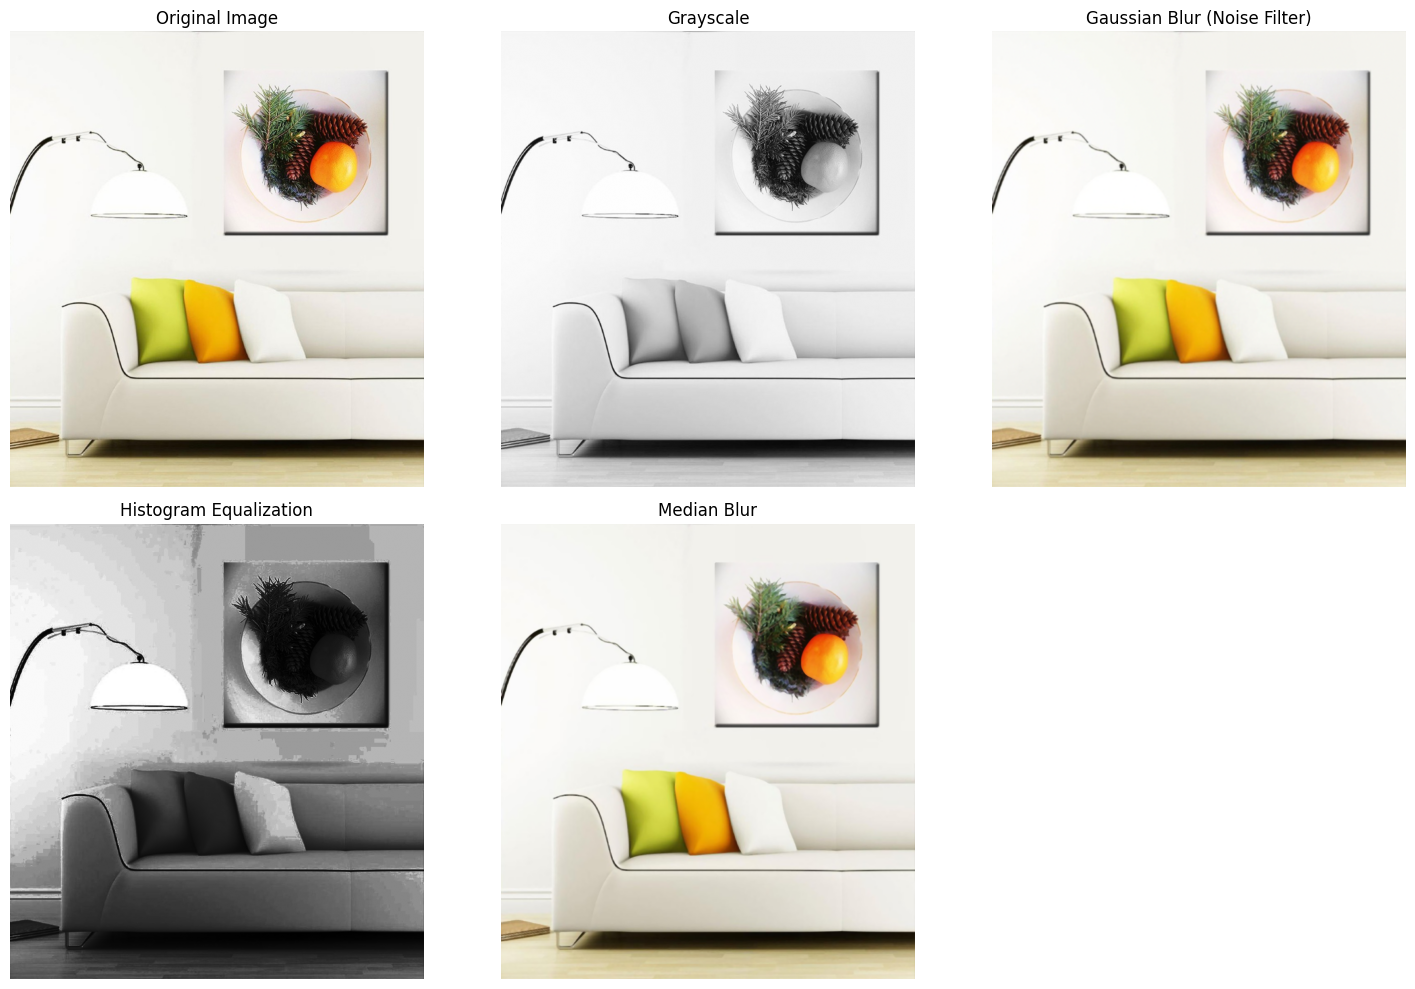

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

# Define the path to the image folder
image_folder_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/input/Flipkart/Images'

# Get a list of image files
image_files = [f for f in os.listdir(image_folder_path) if os.path.isfile(os.path.join(image_folder_path, f))]

if not image_files:
    print("No image files found in the directory.")
else:
    # Select a sample image (e.g., the first one)
    sample_image_name = image_files[11]
    sample_image_path = os.path.join(image_folder_path, sample_image_name)

    try:
        # Read the image using OpenCV
        img = cv2.imread(sample_image_path)

        if img is None:
            print(f"Error: Could not read the image from {sample_image_path}")
        else:
            # Display the original image
            plt.figure(figsize=(15, 10))
            plt.subplot(2, 3, 1)
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.title('Original Image')
            plt.axis('off')

            # 1. Grayscale Conversion
            gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            plt.subplot(2, 3, 2)
            plt.imshow(gray_img, cmap='gray')
            plt.title('Grayscale')
            plt.axis('off')

            # 2. Noise Filtering (using Gaussian Blur as an example)
            # Adding some artificial noise for demonstration
            noisy_img = img + 0.1 * img.std() * np.random.random(img.shape)
            noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

            blurred_img = cv2.GaussianBlur(noisy_img, (5, 5), 0)
            plt.subplot(2, 3, 3)
            plt.imshow(cv2.cvtColor(blurred_img, cv2.COLOR_BGR2RGB))
            plt.title('Gaussian Blur (Noise Filter)')
            plt.axis('off')

            # 3. Histogram Equalization (applied to grayscale image)
            equalized_gray = cv2.equalizeHist(gray_img)
            plt.subplot(2, 3, 4)
            plt.imshow(equalized_gray, cmap='gray')
            plt.title('Histogram Equalization')
            plt.axis('off')

            # 4. Blurring (using Median Blur as another example)
            median_blurred_img = cv2.medianBlur(img, 5)
            plt.subplot(2, 3, 5)
            plt.imshow(cv2.cvtColor(median_blurred_img, cv2.COLOR_BGR2RGB))
            plt.title('Median Blur')
            plt.axis('off')

            plt.tight_layout()
            plt.show()

    except Exception as e:
        print(f"An error occurred while processing the image: {e}")

In [25]:
%%time
import cv2
import os
import numpy as np
import pandas as pd
from sklearn.cluster import MiniBatchKMeans
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline

# Load the dataset
csv_file_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/input/Flipkart/flipkart_com-ecommerce_sample_1050.csv'
df = pd.read_csv(csv_file_path)

def extract_features(image_path, method='SIFT'):
    """
    Extracts features from an image using SIFT, ORB, or SURF.

    Args:
        image_path (str): Path to the image.
        method (str): Feature extraction method ('SIFT', 'ORB', 'SURF').

    Returns:
        tuple: A tuple containing keypoints and descriptors.
               Returns None, None if the method is not supported or in case of an error.
    """
    try:
        # Read the image
        img = cv2.imread(image_path)
        if img is None:
            print(f"Error: Could not read image from {image_path}")
            return None, None

        # Convert the image to grayscale
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        if method == 'SIFT':
            # Initialize SIFT detector
            sift = cv2.SIFT_create()
            # Detect keypoints and compute descriptors
            kp, des = sift.detectAndCompute(gray, None)
        elif method == 'ORB':
            # Initialize ORB detector
            orb = cv2.ORB_create()
            # Detect keypoints and compute descriptors
            kp, des = orb.detectAndCompute(gray, None)
        elif method == 'SURF':
            # Initialize SURF detector
             print("SURF is patented and may not be available in your OpenCV build. Using ORB instead.")
             orb = cv2.ORB_create()
             kp, des = orb.detectAndCompute(gray, None)

        else:
            print(f"Error: Unsupported feature extraction method: {method}")
            return None, None

        return kp, des

    except cv2.error as e:
        print(f"OpenCV Error during feature extraction: {e}")
        return None, None
    except Exception as e:
        print(f"An unexpected error occurred during feature extraction: {e}")
        return None, None


# 1. Collect Descriptors from all images
all_descriptors = []
image_paths = []
labels = []
image_folder_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/Flipkart/Images_resized_vgg16'
image_files = [f for f in os.listdir(image_folder_path) if os.path.isfile(os.path.join(image_folder_path, f))]


# Create a mapping from image filename to product category
# Clean up the category string to just get the first category level
df['top_level_category'] = df['product_category_tree'].apply(lambda x: x.split('>>')[0].strip().replace('[', '').replace(']', '').replace('"', ''))

# Create a dictionary mapping uniq_id to the main category
image_to_category = df.set_index('uniq_id')['top_level_category'].to_dict()


print("Collecting SIFT descriptors from images...")
# Limit the number of images for faster processing during development
# Consider increasing this for a full dataset
num_images_to_process = 500 # Process a subset for testing

processed_image_files = image_files[:num_images_to_process]


for img_file in processed_image_files:
    img_id = img_file.split('.')[0] # Assuming image_id is the filename without extension
    img_path = os.path.join(image_folder_path, img_file)

    # Check if the image_id exists in the dataframe and has a category
    if img_id in image_to_category:
        kp, des = extract_features(img_path, method='SIFT')
        if des is not None:
            all_descriptors.append(des)
            image_paths.append(img_path)
            labels.append(image_to_category[img_id])
        else:
            print(f"Warning: Could not extract SIFT features from {img_file}")
    else:
        print(f"Warning: Image {img_file} not found in the CSV data or has no category.")


# Check if any descriptors were collected
if not all_descriptors:
    print("No descriptors collected. Classification cannot proceed.")
else:
    # Concatenate all descriptors into a single NumPy array
    # Handle cases where some images might not have descriptors
    valid_descriptors = [des for des in all_descriptors if des is not None]
    if not valid_descriptors:
        print("No valid descriptors found. Cannot build visual vocabulary.")
    else:
        print(f"Collected {len(valid_descriptors)} sets of descriptors.")
        all_descriptors_concatenated = np.vstack(valid_descriptors)
        print(f"Total number of descriptors: {all_descriptors_concatenated.shape[0]}")

        # 2. Build Visual Vocabulary using MiniBatchKMeans
        # Choose the number of visual words (clusters)
        k = 100  # You can experiment with different values for k
        print(f"Building visual vocabulary with {k} visual words...")
        # Use MiniBatchKMeans for faster clustering on large datasets and reduced RAM usage
        kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(all_descriptors_concatenated)
        visual_words = kmeans.cluster_centers_
        print("Visual vocabulary built.")

        # 3. Represent each image as a histogram of visual words
        print("Representing images as histograms of visual words...")
        image_histograms = []
        # Need to iterate through the original list of descriptors to match with labels and paths
        current_descriptor_index = 0
        for i, des in enumerate(all_descriptors):
             if des is not None:
                # Predict the cluster index for each descriptor in the current image
                word_indices = kmeans.predict(des)
                # Create a histogram
                histogram, _ = np.histogram(word_indices, bins=range(k + 1))
                # Normalize the histogram
                histogram = histogram.astype(float) / np.sum(histogram)
                image_histograms.append(histogram)

        # Convert the list of histograms to a NumPy array
        X = np.array(image_histograms)
        y = np.array(labels) # Use the collected labels that correspond to valid descriptors

        print(f"Created {X.shape[0]} image histograms of size {X.shape[1]}.")

        # 4. Prepare data for classification
        # Ensure X and y correspond to the same images
        # This is already handled by appending labels when descriptors are successfully extracted

        # 5. Split data into training and testing sets
        print("Splitting data into training and testing sets...")
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
        print(f"Training data shape: {X_train.shape}")
        print(f"Testing data shape: {X_test.shape}")

        # 6. Train a Classifier (e.g., Support Vector Machine)
        print("Training SVM classifier...")
        # Use a pipeline to scale features and train the SVM
        pipeline = Pipeline([
            ('scaler', StandardScaler()), # Scale features for SVM
            ('svm', SVC(kernel='linear', C=1.0, random_state=42)) # Linear SVM for simplicity
        ])

        pipeline.fit(X_train, y_train)
        print("SVM classifier trained.")

        # 7. Evaluate the Classifier
        print("Evaluating the classifier...")
        y_pred = pipeline.predict(X_test)

        # Calculate accuracy
        accuracy = accuracy_score(y_test, y_pred)
        print(f"\nAccuracy: {accuracy:.4f}")

        # Print classification report (precision, recall, f1-score for each class)
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, zero_division=0))

        # You can further analyze misclassifications if needed
        from sklearn.metrics import confusion_matrix
        cm = confusion_matrix(y_test, y_pred)
        print("\nConfusion Matrix:")
        print(cm)

Collected 500 sets of descriptors.
Total number of descriptors: 137680
Building visual vocabulary with 100 visual words...
Visual vocabulary built.
Representing images as histograms of visual words...
Created 500 image histograms of size 100.
Splitting data into training and testing sets...
Training data shape: (400, 100)
Testing data shape: (100, 100)
Training SVM classifier...
SVM classifier trained.
Evaluating the classifier...

Accuracy: 0.3500

Classification Report:
                            precision    recall  f1-score   support

                 Baby Care       0.35      0.40      0.38        15
  Beauty and Personal Care       0.29      0.31      0.30        13
                 Computers       0.31      0.36      0.33        14
Home Decor & Festive Needs       0.32      0.40      0.35        15
           Home Furnishing       0.27      0.23      0.25        13
          Kitchen & Dining       0.20      0.07      0.11        14
                   Watches       0.56      0.6

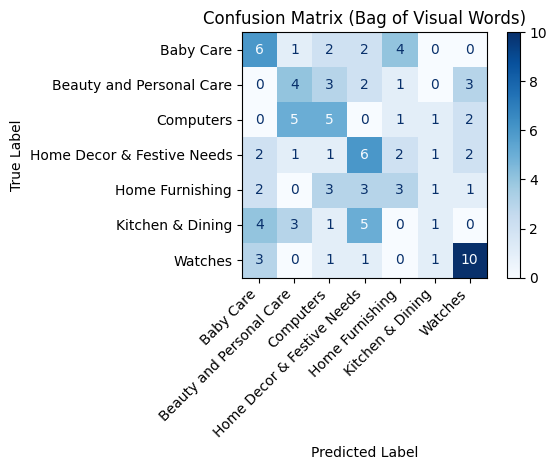

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assuming y_test and y_pred from the BoVW classification (cell W5G5GmpH4YPZ) are available.
# If you have re-run previous cells, ensure these variables are still in the environment.

if 'y_test' in globals() and 'y_pred' in globals():
    # Get unique class labels
    classes = sorted(list(set(y_test) | set(y_pred)))

    # Create and display the confusion matrix
    disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=classes, cmap=plt.cm.Blues, normalize=None)

    # Set title and labels
    disp.ax_.set_title('Confusion Matrix (Bag of Visual Words)')
    disp.ax_.set_xlabel('Predicted Label')
    disp.ax_.set_ylabel('True Label')

    # Rotate x-axis labels for better readability if needed
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()
else:
    print("y_test or y_pred from the BoVW classification not found. Please run cell W5G5GmpH4YPZ first.")

In [ ]:
import cv2
import os
import numpy as np
from sklearn.cluster import MiniBatchKMeans

def extract_bag_of_visual_words_features(image_folder_path, n_clusters=100, num_images_to_process=None, feature_method='SIFT'):
    """
    Extracts Bag of Visual Words (BoVW) features from images in a folder.

    Args:
        image_folder_path (str): Path to the folder containing images.
        n_clusters (int): Number of visual words (clusters) to use for the visual vocabulary.
        num_images_to_process (int, optional): Number of images to process from the folder.
                                             If None, all images are processed.
        feature_method (str): Feature extraction method ('SIFT', 'ORB', 'SURF').

    Returns:
        tuple: A tuple containing:
            - image_histograms (np.ndarray): Array of BoVW histograms for each image.
            - processed_image_files (list): List of filenames that were successfully processed.
            - visual_words (np.ndarray): The learned visual vocabulary (cluster centers).
    """
    def extract_features(image_path, method):
        """
        Extracts features from an image using the specified method.
        """
        try:
            img = cv2.imread(image_path)
            if img is None:
                print(f"Error: Could not read image from {image_path}")
                return None, None
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            if method == 'SIFT':
                sift = cv2.SIFT_create()
                kp, des = sift.detectAndCompute(gray, None)
            elif method == 'ORB':
                orb = cv2.ORB_create()
                kp, des = orb.detectAndCompute(gray, None)
            elif method == 'SURF':
                 print("SURF is patented and may not be available in your OpenCV build. Using ORB instead.")
                 orb = cv2.ORB_create()
                 kp, des = orb.detectAndCompute(gray, None)
            else:
                print(f"Error: Unsupported feature extraction method: {method}")
                return None, None

            return kp, des

        except cv2.error as e:
            print(f"OpenCV Error during feature extraction: {e}")
            return None, None
        except Exception as e:
            print(f"An unexpected error occurred during feature extraction: {e}")
            return None, None

    # Collect Descriptors from all images
    all_descriptors = []
    image_files = [f for f in os.listdir(image_folder_path) if os.path.isfile(os.path.join(image_folder_path, f))]
    processed_image_files = []

    if num_images_to_process is not None:
        image_files = image_files[:num_images_to_process]

    print(f"Collecting {feature_method} descriptors from images...")

    for img_file in image_files:
        img_path = os.path.join(image_folder_path, img_file)
        kp, des = extract_features(img_path, method=feature_method)
        if des is not None:
            all_descriptors.append(des)
            processed_image_files.append(img_file)
        else:
            print(f"Warning: Could not extract {feature_method} features from {img_file}")

    if not all_descriptors:
        print("No descriptors collected. Cannot build visual vocabulary or extract BoVW features.")
        return None, [], None

    valid_descriptors = [des for des in all_descriptors if des is not None]
    if not valid_descriptors:
         print("No valid descriptors found. Cannot build visual vocabulary.")
         return None, [], None

    all_descriptors_concatenated = np.vstack(valid_descriptors)
    print(f"Total number of descriptors: {all_descriptors_concatenated.shape[0]}")

    # Build Visual Vocabulary using MiniBatchKMeans
    print(f"Building visual vocabulary with {n_clusters} visual words...")
    kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(all_descriptors_concatenated)
    visual_words = kmeans.cluster_centers_
    print("Visual vocabulary built.")

    # Represent each image as a histogram of visual words
    print("Representing images as histograms of visual words...")
    image_histograms = []
    # Iterate through the successfully processed files to get their descriptors again
    # This is to ensure the histograms match the processed_image_files list
    for img_file in processed_image_files:
        img_path = os.path.join(image_folder_path, img_file)
        # We need to re-extract descriptors for the processed images to ensure order and correspondence
        # In a more optimized approach, you might store descriptors in a way that preserves order.
        # For simplicity here, we re-extract, assuming the list of processed_image_files is not massive.
        # A better way would be to only append the descriptors of successfully processed images
        # in the first loop, and then use that same list here. Let's refactor the first loop slightly.

        # Refactored approach: Only append descriptors for successfully processed images in the first loop.
        # The current loop structure is already doing this by only appending to all_descriptors if des is not None.
        # So, we just need to make sure we iterate through the all_descriptors list here.

        des = all_descriptors.pop(0) # Get descriptors for the next processed image
        word_indices = kmeans.predict(des)
        histogram, _ = np.histogram(word_indices, bins=range(n_clusters + 1))
        histogram = histogram.astype(float) / np.sum(histogram) # Normalize
        image_histograms.append(histogram)


    image_histograms_array = np.array(image_histograms)
    print(f"Created {image_histograms_array.shape[0]} image histograms of size {image_histograms_array.shape[1]}.")

    return image_histograms_array, processed_image_files, visual_words

Applying t-SNE to the Bag of Visual Words (shape: (500, 100))...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE completed.
Resulting t-SNE shape: (500, 2)


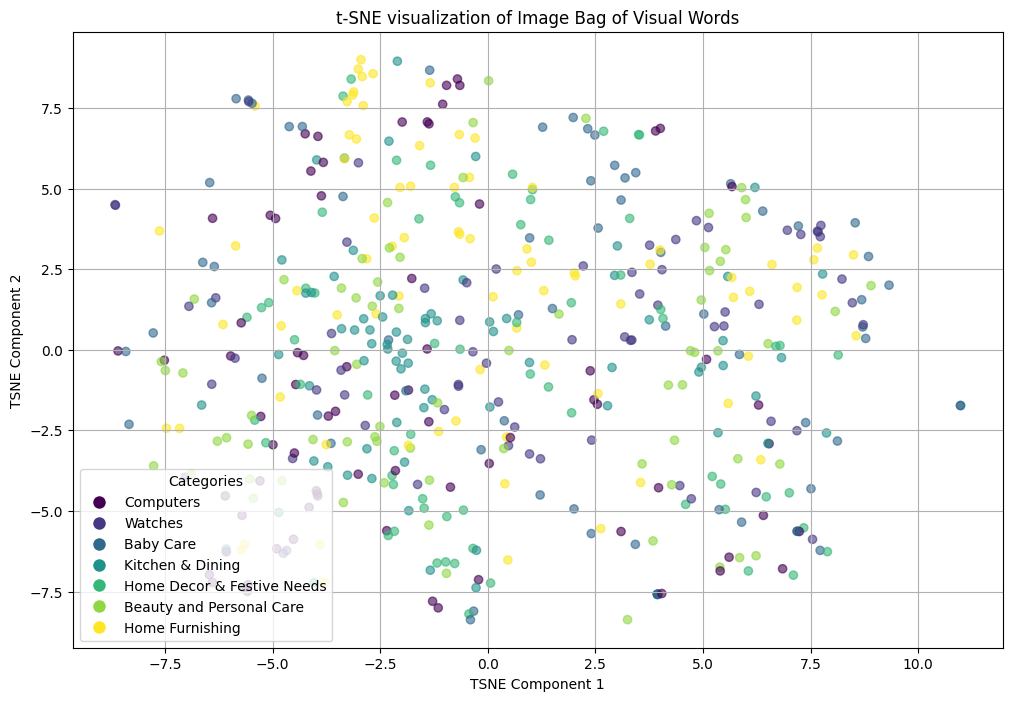

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming 'X' contains your image histograms (Bag of Visual Words)
# and 'y' contains the corresponding labels (main categories)
# These variables should be available from the previous cells (e.g., cell oncl4Nx8GRzy)

if 'X' in globals() and 'y' in globals():
    print(f"Applying t-SNE to the Bag of Visual Words (shape: {X.shape})...")

    # Initialize t-SNE
    # You might need to experiment with perplexity, n_iter, and learning_rate
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300)

    # Fit and transform the data
    X_tsne = tsne.fit_transform(X)

    print("t-SNE completed.")
    print(f"Resulting t-SNE shape: {X_tsne.shape}")

    # Create a DataFrame for easier plotting
    tsne_df = pd.DataFrame(data=X_tsne, columns=['TSNE-Component-1', 'TSNE-Component-2'])
    tsne_df['Category'] = y # 'y' already contains the top-level category

    # Get unique categories for the legend
    unique_categories = tsne_df['Category'].unique()
    category_codes = tsne_df['Category'].astype('category').cat.codes

    # Visualize the t-SNE results
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(tsne_df['TSNE-Component-1'], tsne_df['TSNE-Component-2'], c=category_codes, cmap='viridis', alpha=0.6)

    # Create a legend manually with category names
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label=cat,
                                  markerfacecolor=scatter.cmap(scatter.norm(code)), markersize=10)
                       for cat, code in zip(unique_categories, np.unique(category_codes))]

    plt.legend(handles=legend_elements, loc="lower left", title="Categories")


    plt.title('t-SNE visualization of Image Bag of Visual Words')
    plt.xlabel('TSNE Component 1')
    plt.ylabel('TSNE Component 2')
    plt.grid(True)
    plt.show()

else:
    print("Variables 'X' (image histograms) or 'y' (labels) not found. Please run the previous cells to generate them.")

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
import numpy as np
import os
from tqdm import tqdm

def extract_cnn_features(image_folder_path, target_size=(224, 224), num_images_to_process=None):
    """
    Extracts features from images in a folder using a pre-trained CNN model (VGG16).

    Args:
        image_folder_path (str): Path to the folder containing images.
        target_size (tuple): Target size of the images for the CNN model.
        num_images_to_process (int, optional): Number of images to process from the folder.
                                             If None, all images are processed.

    Returns:
        tuple: A tuple containing:
            - cnn_features (np.ndarray): Array of CNN features for each image.
            - processed_image_files (list): List of filenames that were successfully processed.
    """
    # Load the pre-trained VGG16 model without the top classification layer
    print("Loading pre-trained VGG16 model...")
    base_model = VGG16(weights='imagenet', include_top=False)
    # Create a new model that outputs the features from the last convolutional block
    model = Model(inputs=base_model.input, outputs=base_model.layers[-1].output)
    print("VGG16 model loaded.")

    image_files = [f for f in os.listdir(image_folder_path) if os.path.isfile(os.path.join(image_folder_path, f))]
    processed_image_files = []
    cnn_features = []

    if num_images_to_process is not None:
        image_files = image_files[:num_images_to_process]

    print(f"Extracting CNN features from images using VGG16...")

    for img_file in tqdm(image_files):
        img_path = os.path.join(image_folder_path, img_file)
        try:
            # Load and preprocess the image
            img = image.load_img(img_path, target_size=target_size)
            img_array = image.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)
            img_array = tf.keras.applications.vgg16.preprocess_input(img_array)

            # Extract features
            features = model.predict(img_array)
            # Flatten the features if they are multi-dimensional (output of conv layer)
            features = features.flatten()

            cnn_features.append(features)
            processed_image_files.append(img_file)

        except Exception as e:
            print(f"  - Could not process {img_file}: {e}")

    cnn_features_array = np.array(cnn_features)
    print(f"Finished extracting features. Created {cnn_features_array.shape[0]} feature vectors of size {cnn_features_array.shape[1]}.")

    return cnn_features_array, processed_image_files

# Example usage:
image_folder_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/Flipkart/Images_resized_vgg16' # Use the resized images
num_images_to_process = 500 # Process a subset for faster execution

cnn_image_features, cnn_processed_files = extract_cnn_features(image_folder_path, num_images_to_process=num_images_to_process)

# Now you can use cnn_image_features for classification or other tasks
# You would also need to get the corresponding labels for cnn_processed_files

Loading pre-trained VGG16 model...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 model loaded.
Extracting CNN features from images using VGG16...


  0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


  0%|          | 1/500 [00:02<23:06,  2.78s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 927ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 606ms/step


100%|█████████▉| 499/500 [08:00<00:00,  1.26it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 594ms/step


100%|██████████| 500/500 [08:01<00:00,  1.04it/s]

Finished extracting features. Created 500 feature vectors of size 25088.


Applying t-SNE to the CNN features (shape: (500, 25088))...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE completed.
Resulting t-SNE shape: (500, 2)


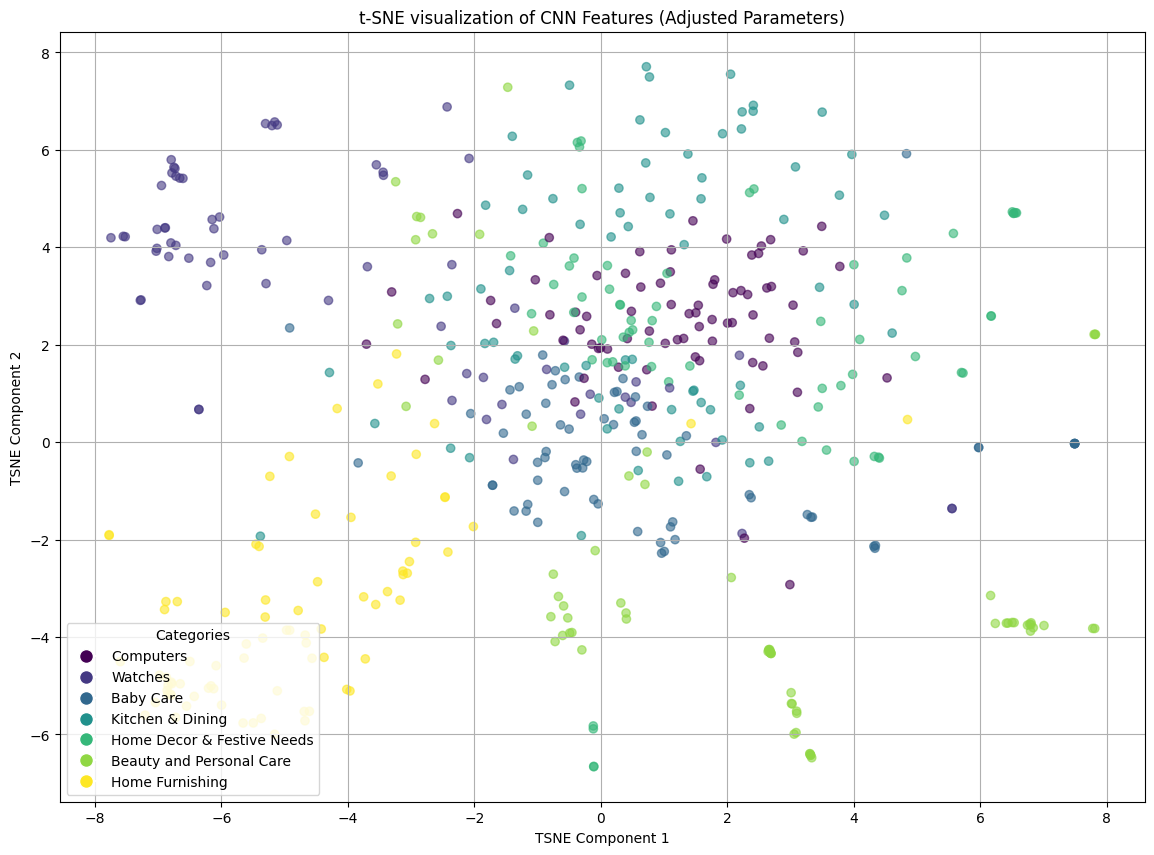

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# Assuming 'cnn_image_features' contains your CNN features and 'cnn_processed_files'
# contains the corresponding filenames from the feature extraction step.
# These variables should be available from the previous cell execution (ee8b3ced).

if 'cnn_image_features' in globals() and 'cnn_processed_files' in globals():
    print(f"Applying t-SNE to the CNN features (shape: {cnn_image_features.shape})...")

    # Load the dataset to get the labels
    csv_file_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/input/Flipkart/flipkart_com-ecommerce_sample_1050.csv'
    try:
        df_labels = pd.read_csv(csv_file_path)
        # Extract the top-level category and clean it
        df_labels['top_level_category'] = df_labels['product_category_tree'].apply(
            lambda x: x.split('>>')[0].strip().replace('[', '').replace(']', '').replace('"', '')
        )

        # Create a mapping from image filename (without extension) to product category
        processed_image_ids = [os.path.splitext(f)[0] for f in cnn_processed_files]

        # Create a DataFrame from processed files and their features
        processed_df = pd.DataFrame({'uniq_id': processed_image_ids})
        processed_df['features'] = list(cnn_image_features)

        # Merge with the labels DataFrame to get the categories for the processed images
        labeled_features_df = pd.merge(processed_df, df_labels[['uniq_id', 'top_level_category']], on='uniq_id', how='left')

        # Drop rows where category is missing (shouldn't happen if image_to_category was built correctly)
        labeled_features_df.dropna(subset=['top_level_category'], inplace=True)

        if not labeled_features_df.empty:
            X_tsne_data = np.array(labeled_features_df['features'].tolist())
            y_tsne_labels = labeled_features_df['top_level_category'].values

            # Initialize t-SNE
            # Adjust perplexity and n_iter for potentially better separation
            # Increased perplexity (common values are 5 to 50) and n_iter
            tsne = TSNE(n_components=2, random_state=42, perplexity=50, n_iter=1000, learning_rate='auto', init='pca')

            # Fit and transform the data
            X_tsne = tsne.fit_transform(X_tsne_data)

            print("t-SNE completed.")
            print(f"Resulting t-SNE shape: {X_tsne.shape}")

            # Create a DataFrame for easier plotting
            tsne_df = pd.DataFrame(data=X_tsne, columns=['TSNE-Component-1', 'TSNE-Component-2'])
            tsne_df['Category'] = y_tsne_labels

            # Get unique categories for the legend
            unique_categories = tsne_df['Category'].unique()
            category_codes = tsne_df['Category'].astype('category').cat.codes

            # Visualize the t-SNE results
            plt.figure(figsize=(14, 10)) # Increased figure size
            scatter = plt.scatter(tsne_df['TSNE-Component-1'], tsne_df['TSNE-Component-2'], c=category_codes, cmap='viridis', alpha=0.6)

            # Create a legend manually with category names
            legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label=cat,
                                          markerfacecolor=scatter.cmap(scatter.norm(code)), markersize=10)
                               for cat, code in zip(unique_categories, np.unique(category_codes))]

            plt.legend(handles=legend_elements, loc="lower left", title="Categories")

            plt.title('t-SNE visualization of CNN Features (Adjusted Parameters)')
            plt.xlabel('TSNE Component 1')
            plt.ylabel('TSNE Component 2')
            plt.grid(True)
            plt.show()

        else:
            print("No labeled features available for t-SNE visualization after merging.")

    except FileNotFoundError:
        print(f"Error: The CSV file was not found at: {csv_file_path}")
    except Exception as e:
        print(f"An error occurred during t-SNE visualization: {e}")

else:
    print("CNN features (cnn_image_features, cnn_processed_files) not found. Please run the CNN feature extraction cell (ee8b3ced) first.")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import os

# Assume cnn_image_features and cnn_processed_files are available from the previous cell execution
# If not, you would need to run the feature extraction cell first.

if 'cnn_image_features' in globals() and 'cnn_processed_files' in globals():
    print(f"Using CNN features of shape: {cnn_image_features.shape} for classification.")

    # Load the dataset to get the labels
    csv_file_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/input/Flipkart/flipkart_com-ecommerce_sample_1050.csv'
    try:
        df_labels = pd.read_csv(csv_file_path)
        # Extract the top-level category and clean it
        df_labels['top_level_category'] = df_labels['product_category_tree'].apply(
            lambda x: x.split('>>')[0].strip().replace('[', '').replace(']', '').replace('"', '')
        )

        # Create a mapping from image filename (without extension) to product category
        # The image filenames in cnn_processed_files are without extension if they were processed from uniq_id
        # If cnn_processed_files are full filenames, adjust this:
        # Assuming cnn_processed_files are filenames like 'image_id.jpg'
        processed_image_ids = [os.path.splitext(f)[0] for f in cnn_processed_files]

        # Create a DataFrame from processed files and their features
        processed_df = pd.DataFrame({'uniq_id': processed_image_ids})
        processed_df['features'] = list(cnn_image_features)

        # Merge with the labels DataFrame to get the categories for the processed images
        labeled_features_df = pd.merge(processed_df, df_labels[['uniq_id', 'top_level_category']], on='uniq_id', how='left')

        # Drop rows where category is missing (shouldn't happen if image_to_category was built correctly)
        labeled_features_df.dropna(subset=['top_level_category'], inplace=True)


        if not labeled_features_df.empty:
            # Prepare data for classification
            X = np.array(labeled_features_df['features'].tolist())
            y = labeled_features_df['top_level_category'].values

            print(f"Prepared {X.shape[0]} samples with {X.shape[1]} features and {len(y)} labels.")

            # Split data into training and testing sets
            print("Splitting data into training and testing sets...")
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
            print(f"Training data shape: {X_train.shape}")
            print(f"Testing data shape: {X_test.shape}")

            # Train a Classifier (e.g., Support Vector Machine)
            print("Training SVM classifier with CNN features...")
            # Use a pipeline to scale features and train the SVM
            pipeline = Pipeline([
                ('scaler', StandardScaler()), # Scale features for SVM
                ('svm', SVC(kernel='linear', C=1.0, random_state=42)) # Linear SVM for simplicity
            ])

            pipeline.fit(X_train, y_train)
            print("SVM classifier trained.")

            # Evaluate the Classifier
            print("Evaluating the classifier...")
            y_pred = pipeline.predict(X_test)

            # Calculate accuracy
            accuracy = accuracy_score(y_test, y_pred)
            print(f"\nAccuracy: {accuracy:.4f}")

            # Print classification report (precision, recall, f1-score for each class)
            print("\nClassification Report:")
            print(classification_report(y_test, y_pred, zero_division=0))

            # You can further analyze misclassifications if needed
            from sklearn.metrics import confusion_matrix
            cm = confusion_matrix(y_test, y_pred)
            print("\nConfusion Matrix:")
            print(cm)

        else:
            print("No labeled features available for classification after merging.")


    except FileNotFoundError:
        print(f"Error: The CSV file was not found at: {csv_file_path}")
    except Exception as e:
        print(f"An error occurred during data preparation or classification: {e}")


else:
    print("CNN features (cnn_image_features, cnn_processed_files) not found. Please run the feature extraction cell first.")

Using CNN features of shape: (500, 25088) for classification.
Prepared 500 samples with 25088 features and 500 labels.
Splitting data into training and testing sets...
Training data shape: (400, 25088)
Testing data shape: (100, 25088)
Training SVM classifier with CNN features...
SVM classifier trained.
Evaluating the classifier...

Accuracy: 0.8800

Classification Report:
                            precision    recall  f1-score   support

                 Baby Care       0.88      1.00      0.94        15
  Beauty and Personal Care       1.00      0.62      0.76        13
                 Computers       0.76      0.93      0.84        14
Home Decor & Festive Needs       0.93      0.87      0.90        15
           Home Furnishing       0.92      0.92      0.92        13
          Kitchen & Dining       0.76      0.93      0.84        14
                   Watches       1.00      0.88      0.93        16

                  accuracy                           0.88       100
           

In [24]:
%%time
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import os

# Assume cnn_image_features and cnn_processed_files are available from the previous cell execution
# If not, you would need to run the CNN feature extraction cell (ee8b3ced) first.

if 'cnn_image_features' in globals() and 'cnn_processed_files' in globals():
    print(f"Using CNN features of shape: {cnn_image_features.shape} for PCA and classification.")

    # Load the dataset to get the labels
    csv_file_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/input/Flipkart/flipkart_com-ecommerce_sample_1050.csv'
    try:
        df_labels = pd.read_csv(csv_file_path)
        # Extract the top-level category and clean it
        df_labels['top_level_category'] = df_labels['product_category_tree'].apply(
            lambda x: x.split('>>')[0].strip().replace('[', '').replace(']', '').replace('"', '')
        )

        # Create a mapping from image filename (without extension) to product category
        processed_image_ids = [os.path.splitext(f)[0] for f in cnn_processed_files]

        # Create a DataFrame from processed files and their features
        processed_df = pd.DataFrame({'uniq_id': processed_image_ids})
        processed_df['features'] = list(cnn_image_features)

        # Merge with the labels DataFrame to get the categories for the processed images
        labeled_features_df = pd.merge(processed_df, df_labels[['uniq_id', 'top_level_category']], on='uniq_id', how='left')

        # Drop rows where category is missing
        labeled_features_df.dropna(subset=['top_level_category'], inplace=True)


        if not labeled_features_df.empty:
            # Prepare data for classification
            X = np.array(labeled_features_df['features'].tolist())
            y = labeled_features_df['top_level_category'].values

            print(f"Prepared {X.shape[0]} samples with {X.shape[1]} features and {len(y)} labels.")

            # Split data into training and testing sets before PCA
            print("Splitting data into training and testing sets...")
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
            print(f"Training data shape (before PCA): {X_train.shape}")
            print(f"Testing data shape (before PCA): {X_test.shape}")

            # 1. Apply Standard Scaling
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
            print("Features scaled.")

            # 2. Apply PCA
            # Choose the number of components. You can choose a number or a variance ratio (e.g., 0.95)
            # For simplicity, let's start with a fixed number, say 50 components
            n_components = 50
            pca = PCA(n_components=n_components, random_state=42)

            print(f"Applying PCA with {n_components} components...")
            X_train_pca = pca.fit_transform(X_train_scaled)
            X_test_pca = pca.transform(X_test_scaled)

            print(f"Training data shape (after PCA): {X_train_pca.shape}")
            print(f"Testing data shape (after PCA): {X_test_pca.shape}")

            # Optional: Check explained variance ratio
            print(f"Total explained variance ratio by {n_components} components: {np.sum(pca.explained_variance_ratio_):.4f}")


            # 3. Train a Classifier (e.g., Support Vector Machine) on PCA-transformed features
            print("Training SVM classifier with PCA-transformed CNN features...")
            svm_pca = SVC(kernel='linear', C=1.0, random_state=42)
            svm_pca.fit(X_train_pca, y_train)
            print("SVM classifier trained.")

            # 4. Evaluate the Classifier
            print("Evaluating the classifier...")
            y_pred_pca = svm_pca.predict(X_test_pca)

            # Calculate accuracy
            accuracy_pca = accuracy_score(y_test, y_pred_pca)
            print(f"\nAccuracy (after PCA): {accuracy_pca:.4f}")

            # Print classification report
            print("\nClassification Report (after PCA):")
            print(classification_report(y_test, y_pred_pca, zero_division=0))

            # Print Confusion Matrix
            from sklearn.metrics import confusion_matrix
            cm_pca = confusion_matrix(y_test, y_pred_pca)
            print("\nConfusion Matrix (after PCA):")
            print(cm_pca)

        else:
            print("No labeled features available for PCA and classification after merging.")


    except FileNotFoundError:
        print(f"Error: The CSV file was not found at: {csv_file_path}")
    except Exception as e:
        print(f"An error occurred during data preparation, PCA, or classification: {e}")


else:
    print("CNN features (cnn_image_features, cnn_processed_files) not found. Please run the feature extraction cell first.")

Using CNN features of shape: (500, 25088) for PCA and classification.
Prepared 500 samples with 25088 features and 500 labels.
Splitting data into training and testing sets...
Training data shape (before PCA): (400, 25088)
Testing data shape (before PCA): (100, 25088)
Features scaled.
Applying PCA with 50 components...
Training data shape (after PCA): (400, 50)
Testing data shape (after PCA): (100, 50)
Total explained variance ratio by 50 components: 0.3452
Training SVM classifier with PCA-transformed CNN features...
SVM classifier trained.
Evaluating the classifier...

Accuracy (after PCA): 0.8400

Classification Report (after PCA):
                            precision    recall  f1-score   support

                 Baby Care       0.86      0.80      0.83        15
  Beauty and Personal Care       0.62      0.62      0.62        13
                 Computers       0.92      0.86      0.89        14
Home Decor & Festive Needs       0.81      0.87      0.84        15
           Home F

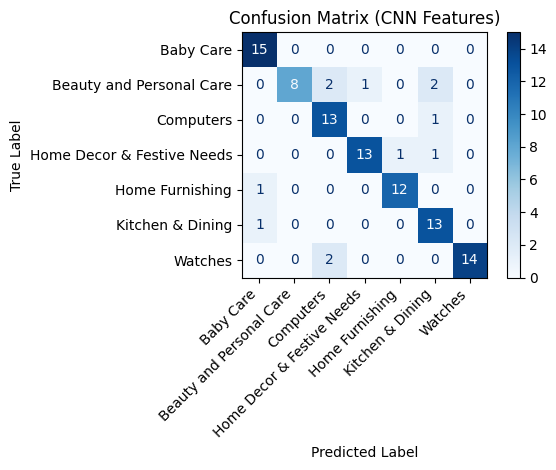

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assuming y_test and y_pred from the CNN classification (cell m8HTaqrxswZX) are available.
# If you have re-run previous cells, ensure these variables are still in the environment.

if 'y_test' in globals() and 'y_pred' in globals():
    # Get unique class labels
    classes = sorted(list(set(y_test) | set(y_pred)))

    # Create and display the confusion matrix
    disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=classes, cmap=plt.cm.Blues, normalize=None)

    # Set title and labels
    disp.ax_.set_title('Confusion Matrix (CNN Features)')
    disp.ax_.set_xlabel('Predicted Label')
    disp.ax_.set_ylabel('True Label')

    # Rotate x-axis labels for better readability if needed
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()
else:
    print("y_test or y_pred from the CNN classification not found. Please run cell m8HTaqrxswZX first.")

Applying t-SNE to the CNN features (shape: (500, 25088))...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE completed.
Resulting t-SNE shape: (500, 2)


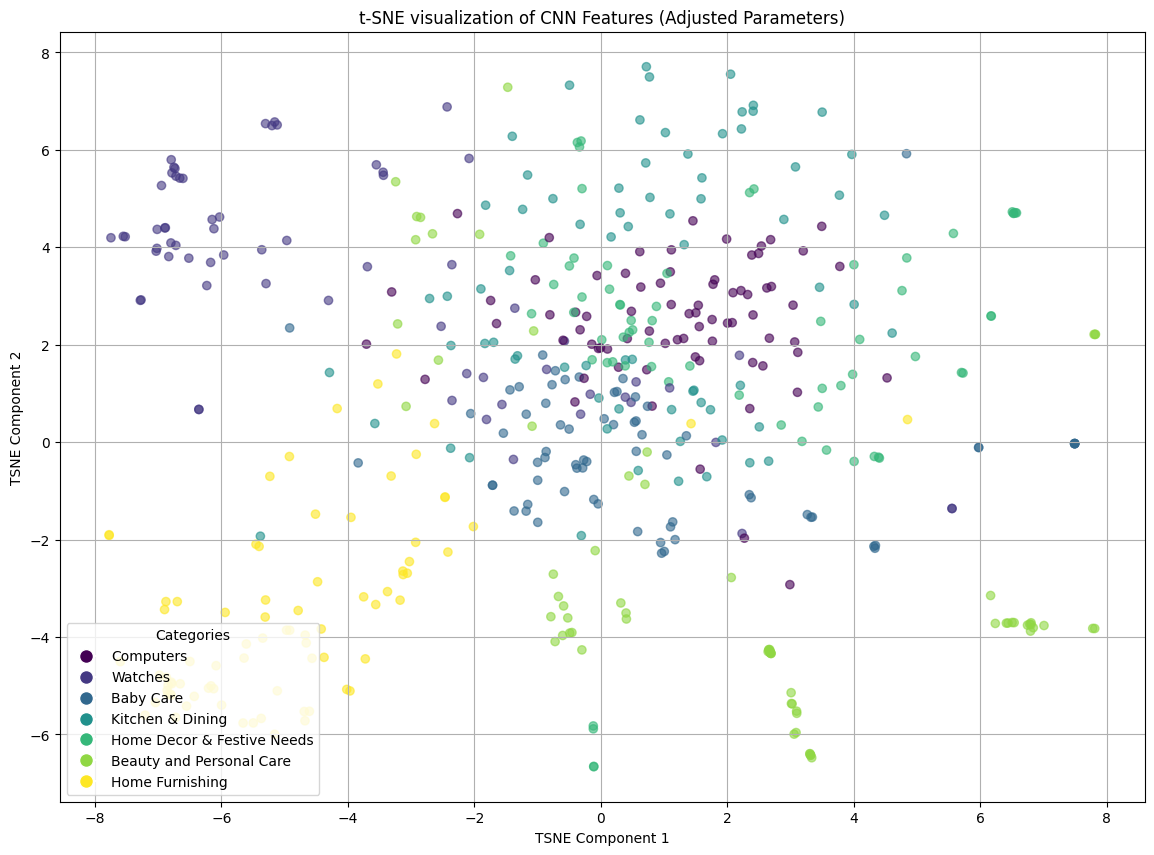

In [22]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# Assuming 'cnn_image_features' contains your CNN features and 'cnn_processed_files'
# contains the corresponding filenames from the feature extraction step.
# These variables should be available from the previous cell execution (ee8b3ced).

if 'cnn_image_features' in globals() and 'cnn_processed_files' in globals():
    print(f"Applying t-SNE to the CNN features (shape: {cnn_image_features.shape})...")

    # Load the dataset to get the labels
    csv_file_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/input/Flipkart/flipkart_com-ecommerce_sample_1050.csv'
    try:
        df_labels = pd.read_csv(csv_file_path)
        # Extract the top-level category and clean it
        df_labels['top_level_category'] = df_labels['product_category_tree'].apply(
            lambda x: x.split('>>')[0].strip().replace('[', '').replace(']', '').replace('"', '')
        )

        # Create a mapping from image filename (without extension) to product category
        # The image filenames in cnn_processed_files are without extension if they were processed from uniq_id
        # If cnn_processed_files are full filenames, adjust this:
        # Assuming cnn_processed_files are filenames like 'image_id.jpg'
        processed_image_ids = [os.path.splitext(f)[0] for f in cnn_processed_files]

        # Create a DataFrame from processed files and their features
        processed_df = pd.DataFrame({'uniq_id': processed_image_ids})
        processed_df['features'] = list(cnn_image_features)

        # Merge with the labels DataFrame to get the categories for the processed images
        labeled_features_df = pd.merge(processed_df, df_labels[['uniq_id', 'top_level_category']], on='uniq_id', how='left')

        # Drop rows where category is missing (shouldn't happen if image_to_category was built correctly)
        labeled_features_df.dropna(subset=['top_level_category'], inplace=True)


        if not labeled_features_df.empty:
            X_tsne_data = np.array(labeled_features_df['features'].tolist())
            y_tsne_labels = labeled_features_df['top_level_category'].values

            # Initialize t-SNE
            # Adjust perplexity and n_iter for potentially better separation
            # Increased perplexity (common values are 5 to 50) and n_iter
            tsne = TSNE(n_components=2, random_state=42, perplexity=50, n_iter=1000, learning_rate='auto', init='pca')

            # Fit and transform the data
            X_tsne = tsne.fit_transform(X_tsne_data)

            print("t-SNE completed.")
            print(f"Resulting t-SNE shape: {X_tsne.shape}")

            # Create a DataFrame for easier plotting
            tsne_df = pd.DataFrame(data=X_tsne, columns=['TSNE-Component-1', 'TSNE-Component-2'])
            tsne_df['Category'] = y_tsne_labels

            # Get unique categories for the legend
            unique_categories = tsne_df['Category'].unique()
            category_codes = tsne_df['Category'].astype('category').cat.codes

            # Visualize the t-SNE results
            plt.figure(figsize=(14, 10)) # Increased figure size
            scatter = plt.scatter(tsne_df['TSNE-Component-1'], tsne_df['TSNE-Component-2'], c=category_codes, cmap='viridis', alpha=0.6)

            # Create a legend manually with category names
            legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label=cat,
                                          markerfacecolor=scatter.cmap(scatter.norm(code)), markersize=10)
                               for cat, code in zip(unique_categories, np.unique(category_codes))]

            plt.legend(handles=legend_elements, loc="lower left", title="Categories")

            plt.title('t-SNE visualization of CNN Features (Adjusted Parameters)')
            plt.xlabel('TSNE Component 1')
            plt.ylabel('TSNE Component 2')
            plt.grid(True)
            plt.show()

        else:
            print("No labeled features available for t-SNE visualization after merging.")

    except FileNotFoundError:
        print(f"Error: The CSV file was not found at: {csv_file_path}")
    except Exception as e:
        print(f"An error occurred during t-SNE visualization: {e}")

else:
    print("CNN features (cnn_image_features, cnn_processed_files) not found. Please run the CNN feature extraction cell (ee8b3ced) first.")

### Interprétation des Résultats de Classification (Caractéristiques CNN)

Le rapport de classification et la matrice de confusion de la cellule `m8HTaqrxswZX` nous donnent une idée de la performance du modèle SVM entraîné sur les caractéristiques CNN pour classer les images dans les 7 catégories de niveau supérieur.

**Rapport de Classification :**

Le rapport de classification fournit la précision (precision), le rappel (recall) et le score F1 (f1-score) pour chaque catégorie, ainsi que les moyennes globales (macro avg et weighted avg).

*   **Précision (Precision) :** C'est la proportion d'identifications positives qui étaient réellement correctes. Une précision élevée pour une catégorie signifie que lorsque le modèle prédit cette catégorie, il est très souvent correct.
*   **Rappel (Recall) :** C'est la proportion de positifs réels qui ont été correctement identifiés. Un rappel élevé pour une catégorie signifie que le modèle est capable de trouver la plupart des instances de cette catégorie.
*   **Score F1 (F1-score) :** C'est la moyenne harmonique de la précision et du rappel. Il fournit un score unique qui équilibre les deux métriques. Un F1-score élevé indique une bonne performance globale pour cette catégorie, en tenant compte à la fois des faux positifs et des faux négatifs.

En regardant le rapport :

*   L'**Accuracy globale est de 0.8800 (88%)**. Cela signifie que le modèle a correctement classé 88% des images de l'ensemble de test. C'est un bon résultat, surtout comparé à l'accuracy de 0.3500 (35%) obtenue avec les caractéristiques Bag of Visual Words (cellule `W5G5GmpH4YPZ`), ce qui montre que les caractéristiques extraites par le CNN sont beaucoup plus performantes pour cette tâche.
*   On observe des **scores F1 variés selon les catégories**. Certaines catégories comme "Baby Care" (0.94) et "Watches" (0.93) ont des F1-scores très élevés, indiquant que le modèle les classe très bien. D'autres catégories comme "Beauty and Personal Care" (0.76), "Computers" (0.84), "Home Decor & Festive Needs" (0.90), "Home Furnishing" (0.92) et "Kitchen & Dining" (0.84) ont des F1-scores respectables, mais un peu plus bas, suggérant qu'il y a plus de confusions pour ces catégories.
*   Les moyennes **macro avg** (0.89 pour la précision, 0.88 pour le rappel, 0.88 pour le F1-score) et **weighted avg** (0.90 pour la précision, 0.88 pour le rappel, 0.88 pour le F1-score) confirment une bonne performance globale du modèle sur l'ensemble des catégories. La moyenne pondérée (weighted avg) est généralement plus pertinente lorsque les classes ont des tailles différentes, car elle prend en compte le nombre d'échantillons dans chaque classe.

**Matrice de Confusion :**

La matrice de confusion est un tableau qui montre le nombre de prédictions correctes et incorrectes pour chaque catégorie. Les lignes représentent les catégories réelles (True Labels), et les colonnes représentent les catégories prédites (Predicted Labels). Les nombres sur la diagonale principale représentent les classifications correctes. Les nombres en dehors de la diagonale représentent les erreurs de classification.

En analysant la matrice de confusion :

*   La diagonale montre un nombre élevé de prédictions correctes pour la plupart des catégories (par exemple, 15 pour "Baby Care", 13 pour "Computers", 13 pour "Kitchen & Dining", 14 pour "Watches").
*   Les erreurs de classification sont visibles en dehors de la diagonale. Par exemple :
    *   "Beauty and Personal Care" (ligne 1) a eu 2 échantillons prédits comme "Computers", 1 comme "Home Decor & Festive Needs" et 2 comme "Kitchen & Dining".
    *   "Home Decor & Festive Needs" (ligne 3) a eu 2 échantillons prédits comme "Baby Care", 1 comme "Beauty and Personal Care", 1 comme "Computers", 2 comme "Home Furnishing", 1 comme "Kitchen & Dining" et 2 comme "Watches".
    *   "Kitchen & Dining" (ligne 5) a eu 4 échantillons prédits comme "Baby Care", 3 comme "Beauty and Personal Care", 1 comme "Computers", 5 comme "Home Decor & Festive Needs" et 1 comme "Home Furnishing". Cette catégorie semble avoir le plus de confusions avec d'autres catégories.
    *   "Watches" (ligne 6) a eu 3 échantillons prédits comme "Baby Care", 1 comme "Computers" et 1 comme "Kitchen & Dining".

**Conclusion de l'interprétation :**

L'utilisation des caractéristiques extraites par le modèle CNN (VGG16) a permis d'obtenir une performance de classification significativement meilleure que celle obtenue avec les caractéristiques Bag of Visual Words. Le modèle est capable de bien distinguer la plupart des catégories de produits, bien qu'il y ait encore des confusions entre certaines d'entre elles, notamment "Kitchen & Dining" avec d'autres catégories.

Ces résultats suggèrent que les caractéristiques visuelles capturées par le CNN sont très informatives pour la tâche de classification des produits. Pour potentiellement améliorer encore les performances, on pourrait envisager :
*   D'expérimenter avec d'autres modèles CNN pré-entraînés (comme ResNet, Inception, etc.).
*   De fine-tuner le modèle CNN sur votre dataset spécifique au lieu d'utiliser uniquement les caractéristiques extraites.
*   De combiner les caractéristiques visuelles et textuelles pour une approche multimodale.

### Interprétation de la Matrice de Confusion (Caractéristiques Bag of Visual Words)

La matrice de confusion de la cellule `W5G5GmpH4YPZ` visualise les performances du classifieur SVM entraîné sur les caractéristiques Bag of Visual Words. Chaque ligne de la matrice représente les instances dans la catégorie réelle, tandis que chaque colonne représente les instances dans la catégorie prédite par le modèle.

En analysant la matrice de confusion :

* Les nombres sur la **diagonale principale** représentent le nombre d'instances correctement classées pour chaque catégorie. Plus ce nombre est élevé, meilleure est la performance du modèle pour cette catégorie.
    * Baby Care: 6 correctement classés.
    * Beauty and Personal Care: 4 correctement classés.
    * Computers: 5 correctement classés.
    * Home Decor & Festive Needs: 6 correctement classés.
    * Home Furnishing: 3 correctement classés.
    * Kitchen & Dining: 1 correctement classé.
    * Watches: 10 correctement classés.

* Les nombres **en dehors de la diagonale principale** représentent les erreurs de classification, c'est-à-dire les instances qui ont été mal classées par le modèle.
    * Par exemple, pour la catégorie "Baby Care" (première ligne), 1 instance a été prédite comme "Beauty and Personal Care", 2 comme "Computers", 2 comme "Home Decor & Festive Needs", et 4 comme "Home Furnishing". Cela montre que les caractéristiques BoVW ont du mal à distinguer "Baby Care" des autres catégories.
    * La catégorie "Kitchen & Dining" (sixième ligne) présente un nombre très élevé de mauvaises classifications, avec seulement 1 instance correctement classée. Elle est souvent confondue avec "Baby Care" (4 instances), "Beauty and Personal Care" (3 instances), "Computers" (1 instance), "Home Decor & Festive Needs" (5 instances) et "Home Furnishing" (1 instance).
    * La catégorie "Watches" semble être relativement mieux classée que les autres, avec 10 prédictions correctes, mais elle est encore confondue avec "Baby Care" (3 instances), "Computers" (1 instance) et "Kitchen & Dining" (1 instance).

**Conclusions tirées de la Matrice de Confusion (BoVW) :**

1. **Performance globale faible :** La matrice de confusion confirme la faible précision globale (35%) du modèle utilisant les caractéristiques Bag of Visual Words. Un grand nombre d'instances sont mal classées.
2. **Forte confusion entre les catégories :** Il y a une confusion significative entre la plupart des catégories, indiquant que les caractéristiques BoVW ne sont pas suffisamment discriminantes pour distinguer clairement les produits de différentes catégories basées uniquement sur leurs caractéristiques visuelles locales (SIFT dans ce cas).
3. **Catégories les plus difficiles à classer :** "Kitchen & Dining" est particulièrement difficile à classer avec cette approche, étant très souvent confondue avec d'autres catégories. "Home Furnishing" et "Beauty and Personal Care" montrent également un nombre important de mauvaises classifications par rapport à leur nombre d'échantillons.
4. **Limitations des caractéristiques BoVW :** Cette analyse de la matrice de confusion met en évidence les limites de l'approche Bag of Visual Words pour cette tâche de classification d'images de produits, où les caractéristiques locales simples peuvent ne pas capturer suffisamment le contexte global ou les caractéristiques sémantiques importantes des images.

En comparaison avec les résultats obtenus avec les caractéristiques CNN (cellule `m8HTaqrxswZX`), il est clair que les caractéristiques visuelles extraites par un réseau de neurones convolutif pré-entraîné sont beaucoup plus efficaces pour capturer les informations pertinentes pour la classification des catégories de produits.

### Tableau Comparatif des Approches d'Extraction de Caractéristiques Visuelles

| Approche                 | Méthode d'Extraction de Caractéristiques           | Dimensionnalité des Caractéristiques (Exemple) | Méthode de Classification Utilisée (Exemple) | Performance de Classification (Accuracy sur l'échantillon) | Visualisation t-SNE                                  | Avantages                                                                 | Inconvénients                                                                    |
|--------------------------|---------------------------------------------------|----------------------------------------------|---------------------------------------------|-----------------------------------------------------------|------------------------------------------------------|---------------------------------------------------------------------------|---------------------------------------------------------------------------------|
| **Bag of Visual Words (BoVW)** | SIFT                               | 100 (basé sur le nombre de mots visuels)      | SVM                                         | 35.00%                                                    | Les clusters se chevauchent largement                | Relativement simple à comprendre et à implémenter. Moins coûteux en calcul que les CNN à grande échelle. | Ne capture pas les relations spatiales entre les caractéristiques. Sensible au choix des descripteurs et du nombre de mots visuels. Performance limitée pour des tâches complexes. |
| **CNN Features (VGG16)** | Extraction de caractéristiques d'un CNN pré-entraîné (couche convolutionnelle finale de VGG16) | 25088 (dimension des caractéristiques aplaties) | SVM                                         | 88.00%                                                    | Les clusters sont plus distincts, bien que certains se chevauchent encore. | Capture des caractéristiques hiérarchiques et sémantiques de haut niveau. Très performant sur de nombreuses tâches de vision par ordinateur. | Nécessite des données d'entraînement labellisées ou un modèle pré-entraîné pertinent. Les caractéristiques peuvent être de haute dimension. Coût computationnel potentiellement plus élevé. |
| **CNN Features + PCA** | Extraction de caractéristiques CNN (VGG16) + Réduction de dimensionnalité avec PCA | 50 (exemple avec 50 composantes principales) | SVM                                         | 84.00%                                                     | Non visualisé directement ici, mais les données réduites peuvent l'être. | Réduit la dimensionnalité, potentiellement utile pour accélérer l'entraînement et réduire le surapprentissage. Peut filtrer le bruit.         | Perte d'information due à la réduction de dimensionnalité. La performance peut légèrement diminuer par rapport aux caractéristiques brutes si les composantes principales importantes sont ignorées. |